# Laboratorio 9

- Mathew Alexander Cordero Aquino 22982
- Pedro Pablo Guzman Mayen  22111

## Preparacion

In [1]:
import collections
import time

import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
import transformers
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision
import numpy as np
import matplotlib.pyplot as plt





In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

Usando: cuda


In [4]:
# Define hyperparameters
num_epochs = 350
batch_size = 64
learning_rate = 0.0002
image_size = 32
image_channels = 3
latent_dim = 100

In [5]:
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


## Generador y Discriminador

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, image_channels=3):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # (N, latent_dim, 1, 1) -> (N, 256, 4, 4)
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # (N, 256, 4, 4) -> (N, 128, 8, 8)
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # (N, 128, 8, 8) -> (N, 64, 16, 16)
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # (N, 64, 16, 16) -> (N, 3, 32, 32)
            nn.ConvTranspose2d(64, image_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


In [7]:
class Discriminator(nn.Module):
    def __init__(self, image_channels=3):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # (N, 3, 32, 32) -> (N, 64, 16, 16)
            nn.Conv2d(image_channels, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (N, 64, 16, 16) -> (N, 128, 8, 8)
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # (N, 128, 8, 8) -> (N, 256, 4, 4)
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # (N, 256, 4, 4) -> (N, 1, 1, 1)
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)


In [8]:
generator = Generator().cuda().to(device)
discriminator = Discriminator().cuda().to(device)

In [9]:
# Define loss and optimizers
criterion = nn.BCELoss()
optimizer_g = torch.optim.Adam(generator.parameters(), lr=learning_rate)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=learning_rate)

Anteriormente se entreno y se obtuvo el siguiente resultado

Epoch [1/1000]  Loss_D: 0.4395  Loss_G: 3.7261
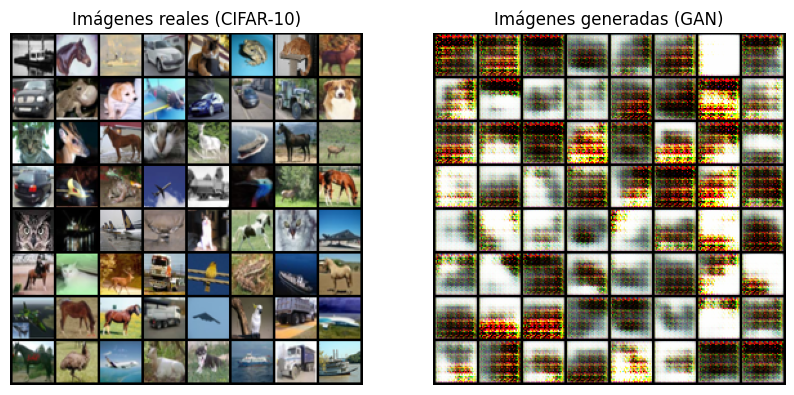

Y la ultima epoca entrenada es

Epoch [958/1000]  Loss_D: 0.3613  Loss_G: 5.5969
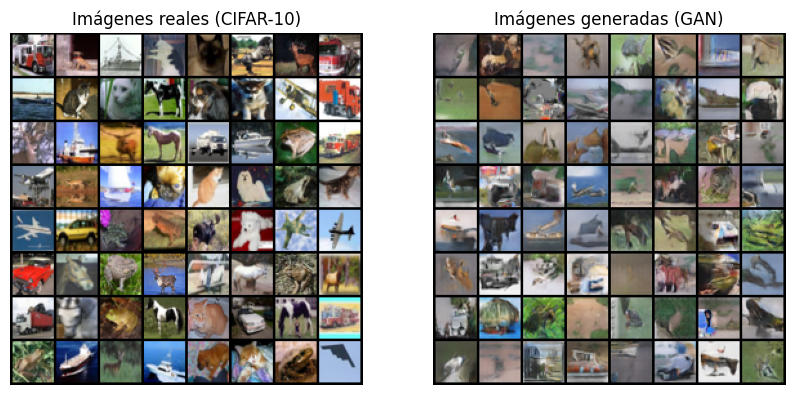

Pero haremos una con imagenes individuales

Epoch [1/350]  Loss_D: 0.8031  Loss_G: 1.8177


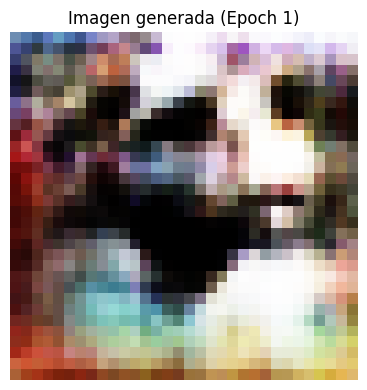

Epoch [2/350]  Loss_D: 0.4420  Loss_G: 3.6303
Epoch [3/350]  Loss_D: 0.4736  Loss_G: 2.8893
Epoch [4/350]  Loss_D: 0.6549  Loss_G: 2.4093
Epoch [5/350]  Loss_D: 1.1434  Loss_G: 2.6455
Epoch [6/350]  Loss_D: 0.5569  Loss_G: 2.7854
Epoch [7/350]  Loss_D: 0.5327  Loss_G: 3.0662
Epoch [8/350]  Loss_D: 0.4154  Loss_G: 3.2975
Epoch [9/350]  Loss_D: 0.3903  Loss_G: 4.0779
Epoch [10/350]  Loss_D: 1.0127  Loss_G: 4.8101
Epoch [11/350]  Loss_D: 0.4010  Loss_G: 4.9939
Epoch [12/350]  Loss_D: 0.4388  Loss_G: 3.1663
Epoch [13/350]  Loss_D: 0.5175  Loss_G: 4.8929
Epoch [14/350]  Loss_D: 0.8124  Loss_G: 3.8024
Epoch [15/350]  Loss_D: 0.4703  Loss_G: 3.1106
Epoch [16/350]  Loss_D: 0.4501  Loss_G: 3.0762
Epoch [17/350]  Loss_D: 1.2664  Loss_G: 3.7398
Epoch [18/350]  Loss_D: 0.4635  Loss_G: 3.4182
Epoch [19/350]  Loss_D: 0.5336  Loss_G: 3.2805
Epoch [20/350]  Loss_D: 0.5129  Loss_G: 3.4512
Epoch [21/350]  Loss_D: 0.4295  Loss_G: 3.5455
Epoch [22/350]  Loss_D: 0.9306  Loss_G: 2.6641
Epoch [23/350]  Loss_

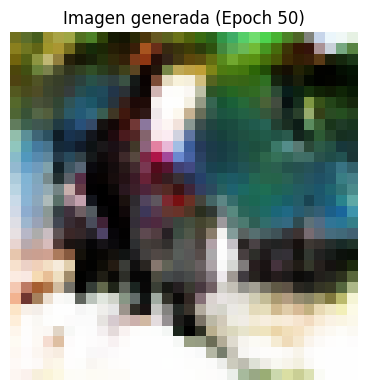

Epoch [51/350]  Loss_D: 0.5312  Loss_G: 2.7165
Epoch [52/350]  Loss_D: 1.7971  Loss_G: 1.6047
Epoch [53/350]  Loss_D: 0.4991  Loss_G: 3.7093
Epoch [54/350]  Loss_D: 0.6317  Loss_G: 2.5422
Epoch [55/350]  Loss_D: 0.5327  Loss_G: 2.9167
Epoch [56/350]  Loss_D: 0.8493  Loss_G: 4.8975
Epoch [57/350]  Loss_D: 1.2501  Loss_G: 1.9926
Epoch [58/350]  Loss_D: 0.4818  Loss_G: 2.4513
Epoch [59/350]  Loss_D: 0.6575  Loss_G: 2.0499
Epoch [60/350]  Loss_D: 0.4722  Loss_G: 2.4035
Epoch [61/350]  Loss_D: 0.5610  Loss_G: 3.1030
Epoch [62/350]  Loss_D: 0.4123  Loss_G: 4.7334
Epoch [63/350]  Loss_D: 0.4780  Loss_G: 2.6717
Epoch [64/350]  Loss_D: 0.4997  Loss_G: 2.0053
Epoch [65/350]  Loss_D: 0.5825  Loss_G: 3.1055
Epoch [66/350]  Loss_D: 0.7883  Loss_G: 2.4143
Epoch [67/350]  Loss_D: 0.6085  Loss_G: 2.9887
Epoch [68/350]  Loss_D: 0.5832  Loss_G: 2.7454
Epoch [69/350]  Loss_D: 0.4245  Loss_G: 4.1203
Epoch [70/350]  Loss_D: 1.0889  Loss_G: 3.7921
Epoch [71/350]  Loss_D: 0.4505  Loss_G: 4.1646
Epoch [72/350

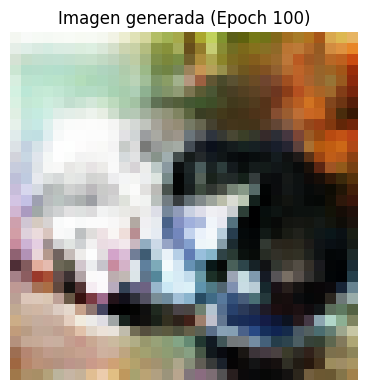

Epoch [101/350]  Loss_D: 0.4527  Loss_G: 3.6327
Epoch [102/350]  Loss_D: 0.4091  Loss_G: 4.3738
Epoch [103/350]  Loss_D: 0.4892  Loss_G: 4.6116
Epoch [104/350]  Loss_D: 0.4630  Loss_G: 3.3788
Epoch [105/350]  Loss_D: 0.6193  Loss_G: 3.3736
Epoch [106/350]  Loss_D: 0.4827  Loss_G: 2.1580
Epoch [107/350]  Loss_D: 0.4353  Loss_G: 5.1391
Epoch [108/350]  Loss_D: 0.4130  Loss_G: 4.3143
Epoch [109/350]  Loss_D: 0.4231  Loss_G: 4.3102
Epoch [110/350]  Loss_D: 0.6063  Loss_G: 2.8101
Epoch [111/350]  Loss_D: 0.4168  Loss_G: 4.8206
Epoch [112/350]  Loss_D: 0.4517  Loss_G: 3.0014
Epoch [113/350]  Loss_D: 0.5887  Loss_G: 2.6691
Epoch [114/350]  Loss_D: 0.5613  Loss_G: 3.7415
Epoch [115/350]  Loss_D: 0.4010  Loss_G: 3.9917
Epoch [116/350]  Loss_D: 0.9808  Loss_G: 3.1128
Epoch [117/350]  Loss_D: 0.4329  Loss_G: 3.5021
Epoch [118/350]  Loss_D: 0.3824  Loss_G: 4.1156
Epoch [119/350]  Loss_D: 0.8386  Loss_G: 3.7530
Epoch [120/350]  Loss_D: 0.3914  Loss_G: 4.3158
Epoch [121/350]  Loss_D: 0.4204  Loss_G:

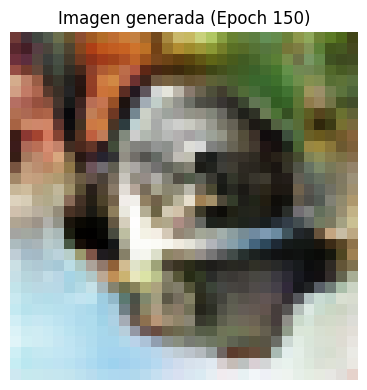

Epoch [151/350]  Loss_D: 0.7550  Loss_G: 4.2535
Epoch [152/350]  Loss_D: 0.7958  Loss_G: 3.2445
Epoch [153/350]  Loss_D: 0.4155  Loss_G: 4.0544
Epoch [154/350]  Loss_D: 0.4654  Loss_G: 3.5676
Epoch [155/350]  Loss_D: 0.3800  Loss_G: 3.9708
Epoch [156/350]  Loss_D: 0.3811  Loss_G: 5.4364
Epoch [157/350]  Loss_D: 0.6702  Loss_G: 3.5605
Epoch [158/350]  Loss_D: 0.5275  Loss_G: 3.5743
Epoch [159/350]  Loss_D: 0.4317  Loss_G: 3.7125
Epoch [160/350]  Loss_D: 0.4388  Loss_G: 4.4606
Epoch [161/350]  Loss_D: 0.7195  Loss_G: 2.9557
Epoch [162/350]  Loss_D: 0.3945  Loss_G: 3.9687
Epoch [163/350]  Loss_D: 0.4736  Loss_G: 2.9110
Epoch [164/350]  Loss_D: 0.6718  Loss_G: 4.1800
Epoch [165/350]  Loss_D: 0.4026  Loss_G: 3.4535
Epoch [166/350]  Loss_D: 0.8459  Loss_G: 4.9850
Epoch [167/350]  Loss_D: 1.3325  Loss_G: 5.4804
Epoch [168/350]  Loss_D: 0.4514  Loss_G: 3.5374
Epoch [169/350]  Loss_D: 0.7197  Loss_G: 4.7395
Epoch [170/350]  Loss_D: 0.5685  Loss_G: 2.8282
Epoch [171/350]  Loss_D: 0.3653  Loss_G:

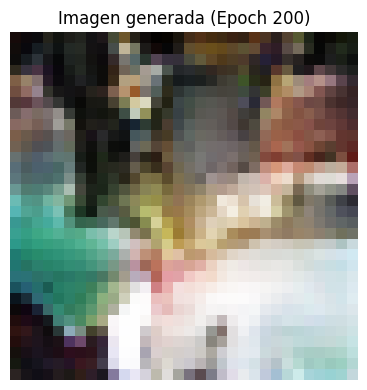

Epoch [201/350]  Loss_D: 0.5119  Loss_G: 3.8081
Epoch [202/350]  Loss_D: 0.4305  Loss_G: 3.3363
Epoch [203/350]  Loss_D: 0.3704  Loss_G: 5.0322
Epoch [204/350]  Loss_D: 0.4297  Loss_G: 5.6496
Epoch [205/350]  Loss_D: 0.4256  Loss_G: 4.8007
Epoch [206/350]  Loss_D: 0.5776  Loss_G: 3.6871
Epoch [207/350]  Loss_D: 0.4367  Loss_G: 2.9335
Epoch [208/350]  Loss_D: 0.4118  Loss_G: 3.8283
Epoch [209/350]  Loss_D: 0.5124  Loss_G: 3.9990
Epoch [210/350]  Loss_D: 0.6954  Loss_G: 3.5017
Epoch [211/350]  Loss_D: 0.4488  Loss_G: 4.6560
Epoch [212/350]  Loss_D: 0.4019  Loss_G: 3.8928
Epoch [213/350]  Loss_D: 0.5929  Loss_G: 2.6112
Epoch [214/350]  Loss_D: 0.4706  Loss_G: 3.5297
Epoch [215/350]  Loss_D: 0.3742  Loss_G: 4.0734
Epoch [216/350]  Loss_D: 0.4301  Loss_G: 5.3833
Epoch [217/350]  Loss_D: 0.4168  Loss_G: 4.3961
Epoch [218/350]  Loss_D: 0.4853  Loss_G: 4.1179
Epoch [219/350]  Loss_D: 0.4862  Loss_G: 3.1087
Epoch [220/350]  Loss_D: 0.4051  Loss_G: 3.5593
Epoch [221/350]  Loss_D: 0.3734  Loss_G:

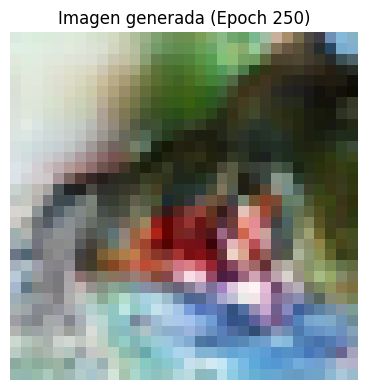

Epoch [251/350]  Loss_D: 0.4372  Loss_G: 3.6581
Epoch [252/350]  Loss_D: 0.5951  Loss_G: 5.4230
Epoch [253/350]  Loss_D: 0.3699  Loss_G: 4.1189
Epoch [254/350]  Loss_D: 0.5752  Loss_G: 4.1998
Epoch [255/350]  Loss_D: 0.3641  Loss_G: 5.0770
Epoch [256/350]  Loss_D: 0.4179  Loss_G: 4.7627
Epoch [257/350]  Loss_D: 0.5241  Loss_G: 3.4273
Epoch [258/350]  Loss_D: 0.4436  Loss_G: 6.0791
Epoch [259/350]  Loss_D: 0.5101  Loss_G: 4.7421
Epoch [260/350]  Loss_D: 0.3810  Loss_G: 3.9879
Epoch [261/350]  Loss_D: 0.3712  Loss_G: 4.7603
Epoch [262/350]  Loss_D: 0.4048  Loss_G: 4.1194
Epoch [263/350]  Loss_D: 0.3723  Loss_G: 4.1325
Epoch [264/350]  Loss_D: 0.5389  Loss_G: 3.1088
Epoch [265/350]  Loss_D: 0.3883  Loss_G: 3.6150
Epoch [266/350]  Loss_D: 0.5460  Loss_G: 4.5486
Epoch [267/350]  Loss_D: 0.4208  Loss_G: 5.1364
Epoch [268/350]  Loss_D: 0.7314  Loss_G: 4.2711
Epoch [269/350]  Loss_D: 0.3722  Loss_G: 4.9996
Epoch [270/350]  Loss_D: 0.4442  Loss_G: 3.3695
Epoch [271/350]  Loss_D: 0.5110  Loss_G:

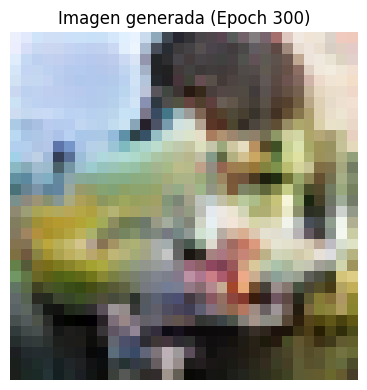

Epoch [301/350]  Loss_D: 0.3713  Loss_G: 4.7875
Epoch [302/350]  Loss_D: 0.4425  Loss_G: 2.6096
Epoch [303/350]  Loss_D: 0.4125  Loss_G: 4.1028
Epoch [304/350]  Loss_D: 0.3737  Loss_G: 4.3310
Epoch [305/350]  Loss_D: 0.6635  Loss_G: 4.8879
Epoch [306/350]  Loss_D: 0.3788  Loss_G: 4.3056
Epoch [307/350]  Loss_D: 0.4903  Loss_G: 4.6970
Epoch [308/350]  Loss_D: 0.7205  Loss_G: 4.6732
Epoch [309/350]  Loss_D: 0.3856  Loss_G: 4.5209
Epoch [310/350]  Loss_D: 0.3714  Loss_G: 4.7786
Epoch [311/350]  Loss_D: 0.5382  Loss_G: 4.9639
Epoch [312/350]  Loss_D: 0.3624  Loss_G: 3.9989
Epoch [313/350]  Loss_D: 0.4249  Loss_G: 3.7010
Epoch [314/350]  Loss_D: 0.3868  Loss_G: 3.2813
Epoch [315/350]  Loss_D: 0.3984  Loss_G: 5.2378
Epoch [316/350]  Loss_D: 0.6023  Loss_G: 2.7801
Epoch [317/350]  Loss_D: 0.4136  Loss_G: 3.9640
Epoch [318/350]  Loss_D: 0.5057  Loss_G: 4.0121
Epoch [319/350]  Loss_D: 0.3714  Loss_G: 4.4134
Epoch [320/350]  Loss_D: 0.3597  Loss_G: 4.4975
Epoch [321/350]  Loss_D: 0.3944  Loss_G:

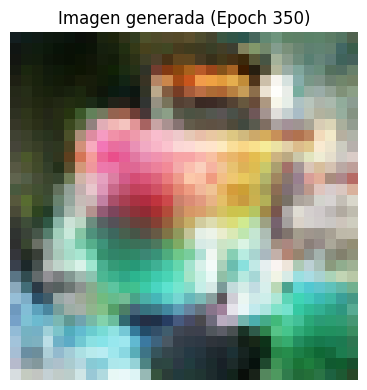

In [13]:
criterion = nn.BCELoss()

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(train_loader):

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # --- Entrenar Discriminador ---
        optimizer_d.zero_grad()

        # Etiquetas: reales = 0.9 (label smoothing), falsas = 0
        real_labels = torch.full((batch_size,), 0.9, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # Salida con imágenes reales
        output_real = discriminator(real_images)
        loss_real = criterion(output_real, real_labels)

        # Generar imágenes falsas
        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake_images = generator(noise)

        # Salida con imágenes falsas (detach evita que G reciba gradientes aquí)
        output_fake = discriminator(fake_images.detach())
        loss_fake = criterion(output_fake, fake_labels)

        # Pérdida total del discriminador
        loss_d = loss_real + loss_fake
        loss_d.backward()
        optimizer_d.step()

        # --- Entrenar Generador ---
        optimizer_g.zero_grad()

        # El generador quiere que el discriminador vea las imágenes falsas como reales
        output_fake_for_g = discriminator(fake_images)
        loss_g = criterion(output_fake_for_g, real_labels)

        loss_g.backward()
        optimizer_g.step()

    # --- Mostrar resultados cada 50 epochs (y la primera) ---
    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss_D: {loss_d.item():.4f}  Loss_G: {loss_g.item():.4f}")

    if (epoch + 1) == 1 or (epoch + 1) % 50 == 0:
        with torch.no_grad():
            # Generar UNA imagen falsa
            sample_noise = torch.randn(1, latent_dim, 1, 1, device=device)
            fake_image = generator(sample_noise).cpu()[0]  # Solo una imagen

            # Normalizar imagen para visualización
            fake_image = (fake_image - fake_image.min()) / (fake_image.max() - fake_image.min())

            # Mostrar solo la imagen generada
            plt.figure(figsize=(4, 4))
            plt.imshow(np.transpose(fake_image, (1, 2, 0)))
            plt.title(f"Imagen generada (Epoch {epoch+1})")
            plt.axis("off")
            plt.tight_layout()
            plt.show()

##  Evaluación de resultados